# Mining Behavior Patterns from Cyclist GPS Trajectories
**CSCI 4900/6000 · Team 3: Steven Gobran & Kevin Yassa · Midterm EDA**

This notebook covers the cleaning and exploratory analysis behind our midterm slides. It uses the SimRa dataset (TU Berlin), June 2023 GitHub batch.

**Files this notebook expects in the same folder:**
- `rides_cl.csv`: one row per cleaned ride, with the features we built (856 rides)
- `incidents.csv`: one row per tagged near-miss incident (408 incidents)
- `points.csv` *(optional)*: every cleaned GPS point, only needed for the trace map

# Main dataset (what the notebook uses)

- SimRa dataset on GitHub: https://github.com/simra-project/dataset
- The exact folder I pulled: Berlin_2023_06 in that repo (877 ride files, the June 2023 batch)
- legend.txt in the same repo explains the codes for bike type, phone position, incident type and who was involved

# Related

- SimRa GitHub org (the app and other project code): https://github.com/simra-project
- SimRa dashboard (good for a screenshot or showing hot spots): https://simra-project.github.io/dashboard/
- Older bulk releases on DepositOnce (from your proposal): https://doi.org/10.14279/depositonce-10605 through https://doi.org/10.14279/depositonce-22968
- OpenStreetMap Berlin road network for map matching (Geofabrik): https://download.geofabrik.de/europe/germany/berlin.html

# Paper
The main SimRa paper is Karakaya et al., "SimRa: Using crowdsourcing to identify near miss hotspots in bicycle traffic," Pervasive and Mobile Computing (2020).

## 0. Setup
Imports, file paths, and the color palette used in the slides.

In [1]:
import os, io, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

DATA_DIR = "."            # folder holding the CSV files
RAW_DIR  = "./rides"      # raw SimRa ride files (only needed for Section 1)
RUN_PARSE = False         # set True to rebuild the CSVs from the raw files

INK, LIGHT, RED, TEAL, MUTED, GRID = "#16242e", "#f3f5f2", "#d9472f", "#2b8a7e", "#5d6b73", "#d9dfdc"
plt.rcParams.update({"font.size": 12, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED})
pd.set_option("display.width", 160)

## 1. Parsing the raw SimRa files (optional)
Each SimRa ride file has two parts split by a line of `=` signs:
1. **Incident block:** `lat, lon, ts, bike, pLoc, incident, i1..i10, scary`
2. **Ride time series:** `lat, lon, X, Y, Z, timeStamp, acc, a, b, c` (GPS about every 3 s, sensor rows in between)

### 1a. Helper functions
Haversine distance (meters) and compass bearing (degrees) between consecutive GPS points.

In [2]:
R_EARTH = 6371000.0

def haversine(lat1, lon1, lat2, lon2):
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi, dlmb = p2 - p1, np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlmb/2)**2
    return 2 * R_EARTH * np.arcsin(np.sqrt(a))

def bearing(lat1, lon1, lat2, lon2):
    p1, p2, dl = np.radians(lat1), np.radians(lat2), np.radians(lon2 - lon1)
    x = np.sin(dl) * np.cos(p2)
    y = np.cos(p1)*np.sin(p2) - np.sin(p1)*np.cos(p2)*np.cos(dl)
    return (np.degrees(np.arctan2(x, y)) + 360) % 360

### 1b. Cleaning rules and feature extraction for one ride
Cleaning:
- Keep only rows that have a GPS fix
- Drop fixes with an accuracy radius over **20 m**
- Drop spikes that imply over **15 m/s (54 km/h)** between fixes
- Drop rides under **300 m** or under **2 minutes**

Features per ride: moving speed, 95th percentile speed, stops (5 s or longer under 1 m/s), share of time stopped, turns (heading change over 45° while moving), acceleration variability, hard braking, and median GPS error.

In [3]:
def parse_ride(path, log):
    txt = open(path, errors="ignore").read()
    parts = txt.split("=========================")
    if len(parts) < 2:
        log["unreadable"] += 1
        return None, None, None
    rid = os.path.basename(path)

    # incident block (first line is the version header)
    try:
        inc = pd.read_csv(io.StringIO(parts[0].split("\n", 1)[1]))
    except Exception:
        inc = pd.DataFrame()
    bike = int(inc["bike"].iloc[0]) if len(inc) else -1
    ploc = int(inc["pLoc"].iloc[0]) if len(inc) else -1
    real = inc[(inc["incident"] > 0) & inc["lat"].notna()] if len(inc) else inc  # <= 0 means no incident

    # ride time series
    body = parts[1].strip().split("\n", 1)[1]
    df = pd.read_csv(io.StringIO(body), usecols=range(10), low_memory=False)
    g = df.dropna(subset=["lat", "lon"])
    n0 = len(g); g = g[g.acc <= 20]; log["bad_acc"] += n0 - len(g)
    g = g.sort_values("timeStamp")
    if len(g) < 10:
        log["short"] += 1; return None, None, None

    # remove speed spikes
    la, lo, t = g.lat.values, g.lon.values, g.timeStamp.values / 1000
    d, dt = haversine(la[:-1], lo[:-1], la[1:], lo[1:]), np.diff(t)
    v = np.where(dt > 0, d / np.where(dt > 0, dt, 1), np.nan)
    spike = v > 15; log["spikes"] += int(np.nansum(spike))
    g = g[np.concatenate([[True], ~spike])]
    la, lo, t = g.lat.values, g.lon.values, g.timeStamp.values / 1000
    if len(g) < 10:
        log["short"] += 1; return None, None, None

    d = haversine(la[:-1], lo[:-1], la[1:], lo[1:])
    dt = np.diff(t).astype(float); dt[dt <= 0] = np.nan
    v = d / dt
    dist, dur = d.sum(), t[-1] - t[0]
    if dist < 300 or dur < 120:
        log["short"] += 1; return None, None, None

    acc = np.diff(v) / dt[1:]
    turn = np.abs((np.diff(bearing(la[:-1], lo[:-1], la[1:], lo[1:])) + 180) % 360 - 180)
    moving = d > 3
    stopped = v < 1.0

    stops, run = 0, 0.0
    for s, step in zip(stopped, np.nan_to_num(dt)):
        if s: run += step
        else:
            stops += run >= 5; run = 0
    stops += run >= 5

    km = dist / 1000
    ride = dict(ride=rid, start=pd.to_datetime(t[0], unit="s"), bike=bike, ploc=ploc, n_gps=len(g),
                dist_km=km, dur_min=dur/60, avg_kmh=dist/dur*3.6,
                moving_kmh=np.nanmean(v[~stopped])*3.6, p95_kmh=np.nanpercentile(v, 95)*3.6,
                stops=int(stops), stops_per_km=stops/km, stop_share=np.nansum(np.where(stopped, dt, 0))/dur,
                turns=int(np.sum((turn > 45) & moving[1:] & moving[:-1])), acc_std=np.nanstd(acc),
                hard_brake=int(np.sum(acc < -2)), gps_acc_med=float(np.median(g.acc)),
                n_inc=len(real), n_scary=int(real["scary"].fillna(0).sum()) if len(real) else 0)
    ride["turns_per_km"] = ride["turns"] / km
    incs = [dict(ride=rid, lat=r.lat, lon=r.lon, type=int(r.incident), scary=int(r.get("scary", 0) or 0),
                 **{f"i{k}": int(r.get(f"i{k}", 0) or 0) for k in range(1, 11)}) for _, r in real.iterrows()]
    pts = pd.DataFrame(dict(ride=rid, lat=la[1:], lon=lo[1:], v=v))
    return ride, incs, pts

### 1c. Run the parser over every raw file
Only runs when `RUN_PARSE = True`. Writes the same CSVs this notebook loads below.

In [4]:
if RUN_PARSE:
    log = dict(files=0, unreadable=0, bad_acc=0, spikes=0, short=0)
    rides, incs, pts = [], [], []
    for f in sorted(glob.glob(os.path.join(RAW_DIR, "VM2_*"))):
        log["files"] += 1
        r, i, p = parse_ride(f, log)
        if r is not None:
            rides.append(r); incs += i; pts.append(p)
    pd.DataFrame(rides).to_csv(os.path.join(DATA_DIR, "rides_cl.csv"), index=False)
    pd.DataFrame(incs).to_csv(os.path.join(DATA_DIR, "incidents.csv"), index=False)
    pd.concat(pts).to_csv(os.path.join(DATA_DIR, "points.csv"), index=False)
    print(log)
else:
    print("Skipping parse, using the existing CSV files.")

Skipping parse, using the existing CSV files.


## 2. Load the cleaned data
Load the ride and incident tables. The GPS point file is optional and only used for the map.

In [5]:
rides = pd.read_csv(os.path.join(DATA_DIR, "rides_cl.csv"), parse_dates=["start"])
incidents = pd.read_csv(os.path.join(DATA_DIR, "incidents.csv"))

# GPS points are optional (only the map uses them). Try the plain CSV first, then the .gz.
# If a file is missing or corrupted, skip it instead of stopping the notebook.
points = None
for name in ["points.csv", "points.csv.gz"]:
    path = os.path.join(DATA_DIR, name)
    if not os.path.exists(path):
        continue
    try:
        points = pd.read_csv(path)
        print(f"Loaded GPS points from {name}")
        break
    except Exception as e:
        print(f"Could not read {name} ({type(e).__name__}: {e}). Skipping it.")

pts_msg = f"{len(points):,}" if points is not None else "not loaded (map will show incidents only)"
print(f"Rides: {len(rides):,}   Incidents: {len(incidents):,}   GPS points: {pts_msg}")
rides.head()

Loaded GPS points from points.csv
Rides: 856   Incidents: 408   GPS points: 375,741


,ride,start,bike,ploc,n_gps,dist_km,dur_min,avg_kmh,moving_kmh,p95_kmh,...,stop_share,turns,turns_per_km,acc_std,hard_brake,gps_acc_med,gps_dt_med,n_inc,n_scary,cl
0,VM2_-1000876027,2023-06-07 19:19:31.000000000,1,0,563,9.348615,28.900000,19.408889,20.548062,34.160053,...,0.064591,8,0.855742,0.731351,9,9.648001,3.0,0,0,0
1,VM2_-1001458476,2023-03-16 20:45:25.000000000,1,0,391,5.352206,19.600000,16.384303,16.748392,23.664259,...,0.025510,17,3.176261,0.457056,3,10.720000,3.0,0,0,0
2,VM2_-100411950,2023-06-05 11:54:23.000000000,1,2,140,1.701239,6.983333,14.616847,15.881349,23.587457,...,0.085919,4,2.351228,0.438209,0,3.100000,3.0,0,0,0
3,VM2_-1008601506,2023-05-31 13:53:39.000000000,0,0,45,0.840306,2.250000,22.408153,23.010860,29.660615,...,0.022222,2,2.380086,0.312549,0,4.000000,3.0,0,0,2
4,VM2_-1012335439,2023-06-27 17:32:19.999000072,1,5,140,2.129381,7.016667,18.208485,21.628855,28.514030,...,0.163895,2,0.939240,0.391512,0,6.000000,3.0,0,0,2


## 3. Data overview
Column types, missing values, and total coverage.

In [6]:
print(rides.dtypes.to_string())
print("\nMissing values per column:")
print(rides.isna().sum()[rides.isna().sum() > 0].to_string() or "none")
print(f"\nTotal distance: {rides.dist_km.sum():,.0f} km")
print(f"Ride dates: {rides.start.min().date()} to {rides.start.max().date()}")

ride                       str
start           datetime64[ns]
bike                     int64
ploc                     int64
n_gps                    int64
dist_km                float64
dur_min                float64
avg_kmh                float64
moving_kmh             float64
p95_kmh                float64
stops                    int64
stops_per_km           float64
stop_share             float64
turns                    int64
turns_per_km           float64
acc_std                float64
hard_brake               int64
gps_acc_med            float64
gps_dt_med             float64
n_inc                    int64
n_scary                  int64
cl                       int64

Missing values per column:
Series([], )

Total distance: 4,936 km
Ride dates: 2023-01-02 to 2023-06-30


### 3a. Label the coded columns
SimRa stores bike type and phone location as numbers. These maps come from the dataset's `legend.txt`.

In [7]:
BIKE = {0: "Not chosen", 1: "City/Trekking", 2: "Road racing", 3: "E-bike", 4: "Recumbent",
        5: "Freight", 6: "Tandem", 7: "Mountain", 8: "Other"}
PLOC = {0: "Pocket", 1: "Handlebar", 2: "Jacket pocket", 3: "Hand", 4: "Basket/Pannier", 5: "Backpack/Bag", 6: "Other"}
INC  = {1: "Close pass", 2: "Pulling in / out", 3: "Near left/right hook", 4: "Head-on approach",
        5: "Tailgating", 6: "Near-dooring", 7: "Dodging obstacle", 8: "Other"}
PARTY = {"i1": "Bus", "i2": "Cyclist", "i3": "Pedestrian", "i4": "Delivery van", "i5": "Truck",
         "i6": "Motorcycle", "i7": "Car", "i8": "Taxi", "i9": "Other", "i10": "E-scooter"}

rides["bike_label"] = rides.bike.map(BIKE)
rides["ploc_label"] = rides.ploc.map(PLOC)
incidents["type_label"] = incidents.type.map(INC)

display(rides.bike_label.value_counts().to_frame("rides"))
display(rides.ploc_label.value_counts().to_frame("rides"))

,rides
bike_label,
City/Trekking,663
Not chosen,118
E-bike,42
Road racing,22
Other,11


,rides
ploc_label,
Pocket,603
Backpack/Bag,117
Basket/Pannier,78
Handlebar,31
Jacket pocket,27


## 4. Summary statistics
Mean, median, and standard deviation for the main ride features (the table on the stats slide).

In [8]:
FEATURES = {"dist_km": "Distance (km)", "dur_min": "Duration (min)", "moving_kmh": "Moving speed (km/h)",
            "p95_kmh": "95th pct speed (km/h)", "stops_per_km": "Stops per km", "stop_share": "Share of time stopped",
            "turns_per_km": "Turns per km", "gps_acc_med": "GPS error radius (m)"}
summary = rides[list(FEATURES)].agg(["mean", "median", "std"]).T.round(2)
summary.index = summary.index.map(FEATURES)
summary

,mean,median,std
Distance (km),5.77,4.10,5.44
Duration (min),22.33,15.53,26.23
Moving speed (km/h),18.50,18.48,2.98
95th pct speed (km/h),26.54,26.33,4.74
Stops per km,1.51,1.18,1.74
Share of time stopped,0.14,0.11,0.11
Turns per km,2.16,1.68,2.01
GPS error radius (m),6.54,5.36,3.77


## 5. Incident statistics
How common near-misses are, which types show up most, and who is involved.

In [9]:
n_inc = len(incidents)
print(f"Incidents: {n_inc}  in {(rides.n_inc > 0).sum()} rides ({(rides.n_inc > 0).mean():.0%} of rides)")
print(f"Marked scary: {incidents.scary.sum()} ({incidents.scary.mean():.0%})")
print(f"Incidents per 100 km: {n_inc / rides.dist_km.sum() * 100:.1f}")

by_type = incidents.groupby("type_label").agg(count=("type", "size"), scary_rate=("scary", "mean"))
by_type["share"] = by_type["count"] / n_inc
display(by_type.sort_values("count", ascending=False).round(2))

party = incidents[list(PARTY)].sum().rename(PARTY).sort_values(ascending=False)
display((party / n_inc).round(2).to_frame("share of incidents"))

Incidents: 408  in 143 rides (17% of rides)
Marked scary: 106 (26%)
Incidents per 100 km: 8.3


,count,scary_rate,share
type_label,,,
Close pass,206,0.32,0.50
Dodging obstacle,82,0.07,0.20
Tailgating,44,0.11,0.11
Head-on approach,27,0.52,0.07
Near left/right hook,25,0.36,0.06
Pulling in / out,13,0.31,0.03
Other,11,0.18,0.03


,share of incidents
Car,0.73
Delivery van,0.06
Pedestrian,0.05
Cyclist,0.05
Taxi,0.05
Bus,0.02
Truck,0.02
Motorcycle,0.02
Other,0.01
E-scooter,0.01


## 6. Visualization 1: ride traces and incidents across Berlin
Each GPS point is colored by speed (brighter = faster). Red dots are incidents, larger ones were marked scary. If `points.csv` is missing, only incidents are plotted.

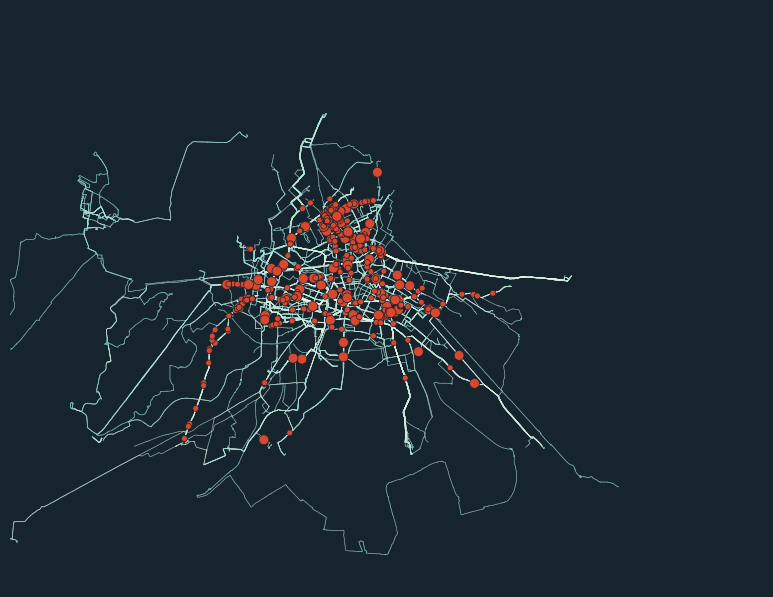

In [10]:
fig, ax = plt.subplots(figsize=(10, 7.5), facecolor=INK)
ax.set_facecolor(INK)
if points is not None:
    p = points[points.lat.between(52.33, 52.68) & points.lon.between(13.08, 13.76)]
    kmh = np.clip(p.v * 3.6, 0, 35)
    order = np.argsort(kmh.values)
    cmap = LinearSegmentedColormap.from_list("speed", ["#4f7488", "#8fd3c6", "#fbf8ee"])
    ax.scatter(p.lon.values[order], p.lat.values[order], c=kmh.values[order], cmap=cmap, s=0.3, alpha=0.55, linewidths=0)
ax.scatter(incidents.lon, incidents.lat, s=np.where(incidents.scary == 1, 50, 18), c=RED, edgecolors=INK, linewidths=0.5)
ax.set_aspect(1 / np.cos(np.radians(52.5)))
ax.set_xlim(13.12, 13.72); ax.set_ylim(52.36, 52.64); ax.axis("off")
plt.show()

## 7. Visualization 2: speed and stopping distributions
Left: average moving speed per ride. Right: stops per km (capped at 6 so the tail is readable).

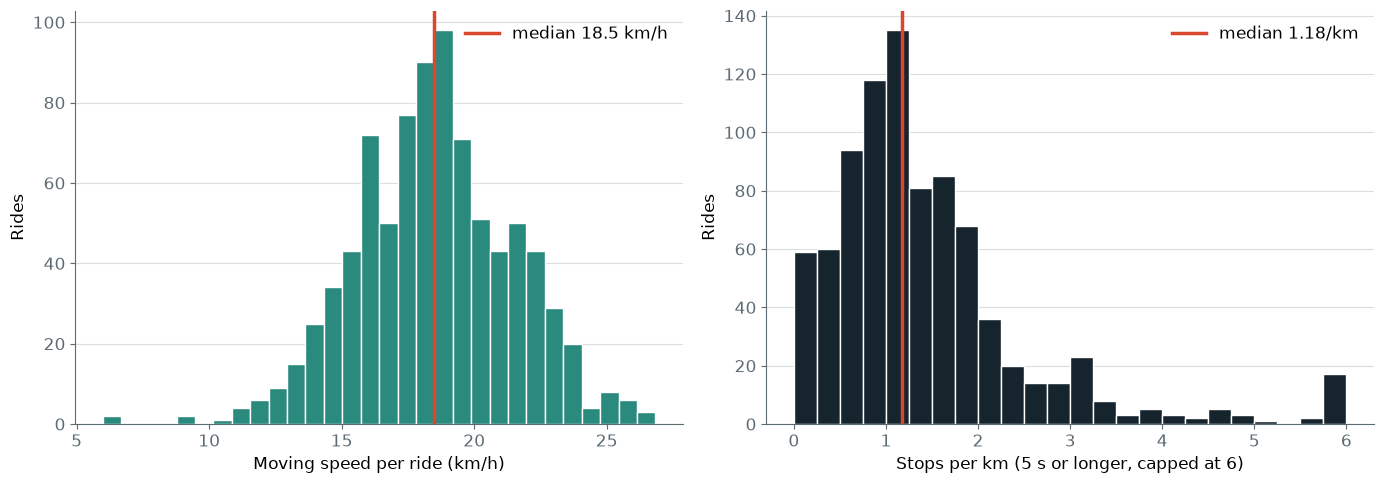

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].hist(rides.moving_kmh, bins=30, color=TEAL, edgecolor="white")
axs[0].axvline(rides.moving_kmh.median(), color=RED, lw=2.5, label=f"median {rides.moving_kmh.median():.1f} km/h")
axs[0].set(xlabel="Moving speed per ride (km/h)", ylabel="Rides")

axs[1].hist(rides.stops_per_km.clip(upper=6), bins=np.arange(0, 6.25, 0.25), color=INK, edgecolor="white")
axs[1].axvline(rides.stops_per_km.median(), color=RED, lw=2.5, label=f"median {rides.stops_per_km.median():.2f}/km")
axs[1].set(xlabel="Stops per km (5 s or longer, capped at 6)", ylabel="Rides")
for a in axs:
    a.legend(frameon=False); a.grid(axis="y", color=GRID); a.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 8. Visualization 3: feature correlations
Spearman correlation (rank based, so skewed features like distance don't dominate).

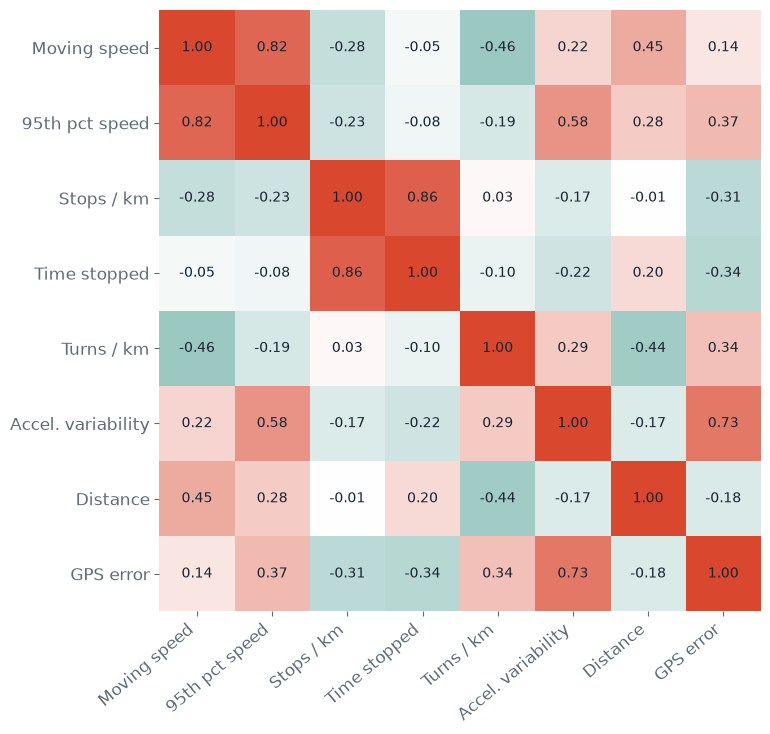

Turns/km vs moving speed:       -0.46
Stops/km vs time stopped:       0.86
Accel. variability vs GPS error: 0.73


In [12]:
CORR_COLS = {"moving_kmh": "Moving speed", "p95_kmh": "95th pct speed", "stops_per_km": "Stops / km",
             "stop_share": "Time stopped", "turns_per_km": "Turns / km", "acc_std": "Accel. variability",
             "dist_km": "Distance", "gps_acc_med": "GPS error"}
corr = rides[list(CORR_COLS)].corr(method="spearman")
labels = list(CORR_COLS.values())

fig, ax = plt.subplots(figsize=(9, 7.5))
cmap = LinearSegmentedColormap.from_list("div", [TEAL, "#ffffff", RED])
ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=40, ha="right")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=10, color=INK)
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout(); plt.show()

print("Turns/km vs moving speed:      ", round(corr.loc["turns_per_km", "moving_kmh"], 2))
print("Stops/km vs time stopped:      ", round(corr.loc["stops_per_km", "stop_share"], 2))
print("Accel. variability vs GPS error:", round(corr.loc["acc_std", "gps_acc_med"], 2))

## 9. Visualization 4: incident types
Gray bars are all incidents of each type; the red part is the share marked scary.

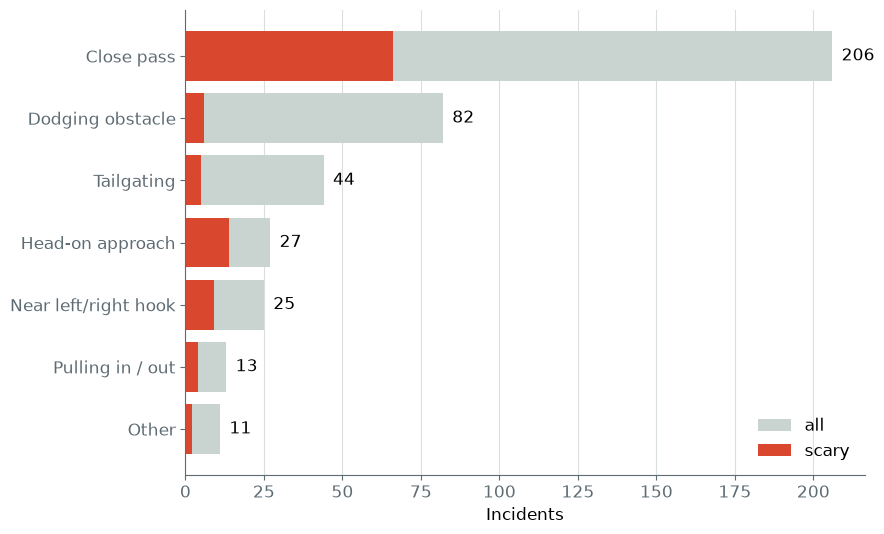

In [13]:
counts = incidents.type_label.value_counts().sort_values()
scary = incidents[incidents.scary == 1].type_label.value_counts().reindex(counts.index).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(counts.index, counts.values, color="#c9d3cf", label="all")
ax.barh(counts.index, scary.values, color=RED, label="scary")
for k, v in enumerate(counts.values):
    ax.text(v + 3, k, str(v), va="center")
ax.set_xlabel("Incidents"); ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", color=GRID); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 10. Preliminary clustering of riding styles
K-means on six standardized features. The count-based features and acceleration variability are log transformed first because they are heavily right skewed.

### 10a. Pick k
Silhouette score for k = 2 to 6 (higher is better separated).

In [14]:
CLUSTER_FEATURES = ["moving_kmh", "p95_kmh", "stops_per_km", "stop_share", "turns_per_km", "acc_std"]
X = rides[CLUSTER_FEATURES].copy()
X["stops_per_km"] = np.log1p(X.stops_per_km)
X["turns_per_km"] = np.log1p(X.turns_per_km)
X["acc_std"] = np.log(X.acc_std)
Z = StandardScaler().fit_transform(X)

for k in range(2, 7):
    labels_k = KMeans(n_clusters=k, n_init=20, random_state=0).fit_predict(Z)
    print(f"k={k}  silhouette={silhouette_score(Z, labels_k):.3f}")

k=2  silhouette=0.270
k=3  silhouette=0.246
k=4  silhouette=0.258
k=5  silhouette=0.251
k=6  silhouette=0.245


### 10b. Fit k = 3 and profile each cluster
Clusters are named from their medians: the one with the worst GPS error is the noisy-GPS group, and of the other two the slower one is stop-and-go.

In [15]:
rides["cluster"] = KMeans(n_clusters=3, n_init=20, random_state=0).fit_predict(Z)

profile = rides.groupby("cluster")[CLUSTER_FEATURES + ["dist_km", "gps_acc_med"]].median()
noisy = profile.gps_acc_med.idxmax()
rest = profile.drop(noisy)
stopgo = rest.moving_kmh.idxmin()
cruise = rest.moving_kmh.idxmax()
NAMES = {noisy: "Noisy-GPS rides", stopgo: "Stop-and-go", cruise: "Steady cruisers"}
rides["cluster_name"] = rides.cluster.map(NAMES)

profile.index = profile.index.map(NAMES)
profile["rides"] = rides.cluster_name.value_counts()
profile["phone_in_pocket"] = rides.groupby("cluster_name").ploc.apply(lambda s: (s == 0).mean())
profile["e_bike_share"] = rides.groupby("cluster_name").bike.apply(lambda s: (s == 3).mean())
profile.round(2)

,moving_kmh,p95_kmh,stops_per_km,stop_share,turns_per_km,acc_std,dist_km,gps_acc_med,rides,phone_in_pocket,e_bike_share
cluster,,,,,,,,,,,
Noisy-GPS rides,18.45,27.63,0.93,0.08,2.50,0.58,3.86,10.72,327,0.96,0.00
Stop-and-go,15.64,21.68,1.96,0.18,2.26,0.27,3.33,3.10,242,0.45,0.04
Steady cruisers,21.41,28.77,1.12,0.13,0.72,0.32,7.50,4.00,287,0.63,0.11


## 11. Visualization 5: riding style clusters
Moving speed against stops per km, colored by cluster.

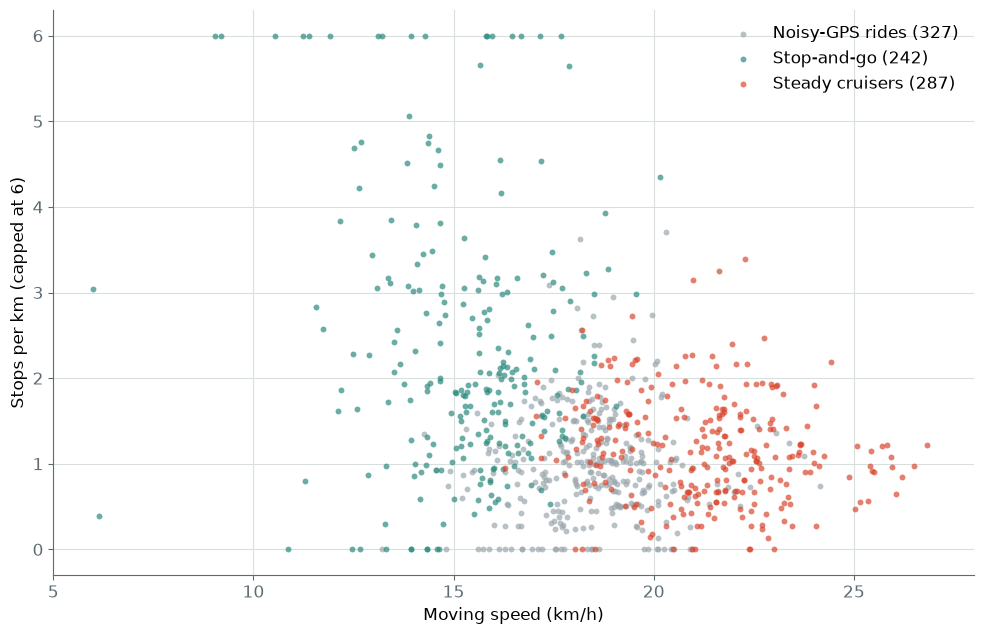

In [16]:
COLORS = {"Noisy-GPS rides": "#9aa7ad", "Stop-and-go": TEAL, "Steady cruisers": RED}
fig, ax = plt.subplots(figsize=(10, 6.5))
for name, color in COLORS.items():
    d = rides[rides.cluster_name == name]
    ax.scatter(d.moving_kmh, d.stops_per_km.clip(upper=6), s=18, alpha=0.7, color=color,
               label=f"{name} ({len(d)})", linewidths=0)
ax.set(xlabel="Moving speed (km/h)", ylabel="Stops per km (capped at 6)", xlim=(5, 28))
ax.legend(frameon=False); ax.grid(color=GRID); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 12. Key insights so far
- **Typical ride:** about 4 km and 15 minutes, at about 18.5 km/h while moving. Distance and duration are right skewed.
- **Stops:** most rides stop about once per km, but a long tail of rides stop constantly (stop-and-go riding).
- **Turns slow riders down:** more turns per km goes with lower moving speed.
- **Near-misses:** about half are close passes, most involve a car, and head-on approaches are the scariest.
- **GPS noise is a real problem:** acceleration variability tracks GPS error closely, and one of the three clusters is driven by phone position (almost all in a pocket), not by riding style.

**Next steps:** map-match rides to the OpenStreetMap Berlin network, smooth GPS and control for phone position, scale up to more batches, then re-cluster and summarize by street segment and junction.